<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_07_notch_inverse_wiener_filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 07**

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

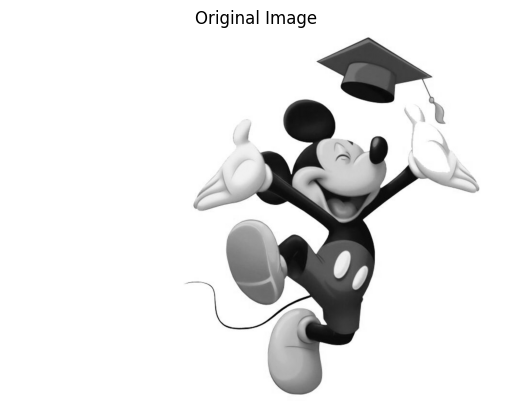

In [3]:
img = cv2.imread('image.jpeg',0)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

### PART 1 — Periodic Noise + Bandpass (extract noise)

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

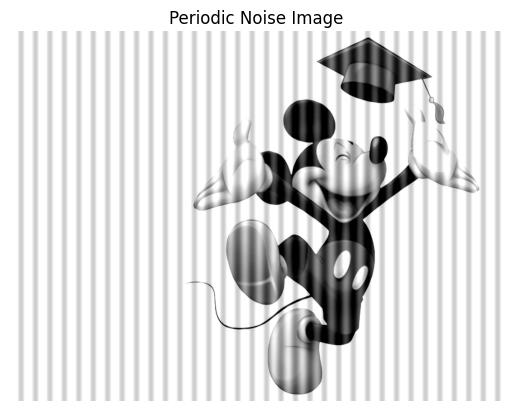

In [4]:
rows, cols = img.shape
x = np.arange(cols)
y = np.arange(rows)
x,y = np.meshgrid(x,y)

periodic = 50*np.sin(2*np.pi*x/30)

noisy = np.clip(img + periodic,0,255).astype(np.uint8)

plt.imshow(noisy, cmap='gray')
plt.title("Periodic Noise Image")
plt.axis('off')

In [5]:
def butter_bandpass(shape, d0, w, n):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D == 0:
                D = 1
            H[i,j] = 1 / (1 + ((D*w)/(D**2 - d0**2))**(2*n))
    return H

/tmp/ipykernel_7818/3655864131.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  H[i,j] = 1 / (1 + ((D*w)/(D**2 - d0**2))**(2*n))


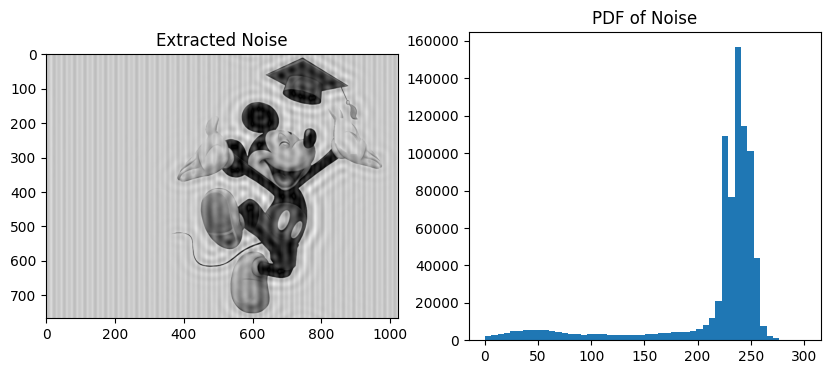

In [6]:
f = np.fft.fft2(noisy)
fshift = np.fft.fftshift(f)

H = butter_bandpass(img.shape,30,10,2)

noise_freq = fshift * H
noise = np.abs(np.fft.ifft2(np.fft.ifftshift(noise_freq)))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noise, cmap='gray')
plt.title("Extracted Noise")

plt.subplot(1,2,2)
plt.hist(noise.ravel(), bins=50)
plt.title("PDF of Noise")

plt.show()

### PART 2 — Notch Reject Filters

In [7]:
def ideal_notch(shape, d0):
    rows, cols = shape
    H = np.ones((rows,cols))
    crow, ccol = rows//2, cols//2

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D < d0:
                H[i,j] = 0
    return H

def gaussian_notch(shape, d0):
    rows, cols = shape
    H = np.zeros((rows,cols))
    crow, ccol = rows//2, cols//2

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            H[i,j] = 1 - np.exp(-(D**2)/(2*d0**2))
    return H

def butter_notch(shape, d0, n):
    rows, cols = shape
    H = np.zeros((rows,cols))
    crow, ccol = rows//2, cols//2

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D == 0:
                D = 1
            H[i,j] = 1/(1+(d0/D)**(2*n))
    return H

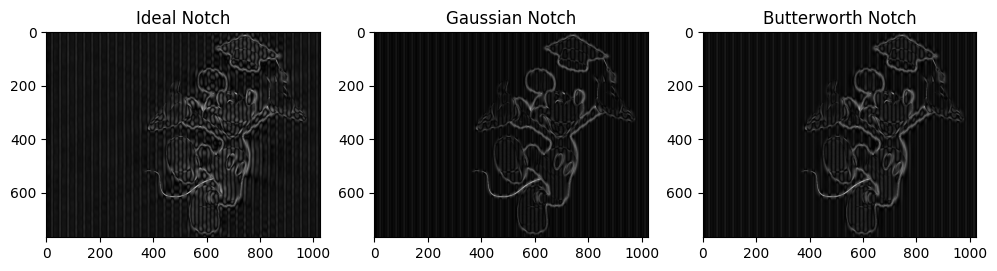

In [8]:
f = np.fft.fft2(noisy)
fshift = np.fft.fftshift(f)

ideal = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * ideal_notch(img.shape,30))))
gauss = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * gaussian_notch(img.shape,30))))
butter = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * butter_notch(img.shape,30,2))))

plt.figure(figsize=(12,4))

plt.subplot(131); plt.imshow(ideal,cmap='gray'); plt.title("Ideal Notch")
plt.subplot(132); plt.imshow(gauss,cmap='gray'); plt.title("Gaussian Notch")
plt.subplot(133); plt.imshow(butter,cmap='gray'); plt.title("Butterworth Notch")

plt.show()

### PART 3 — Inverse & Wiener Filtering

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

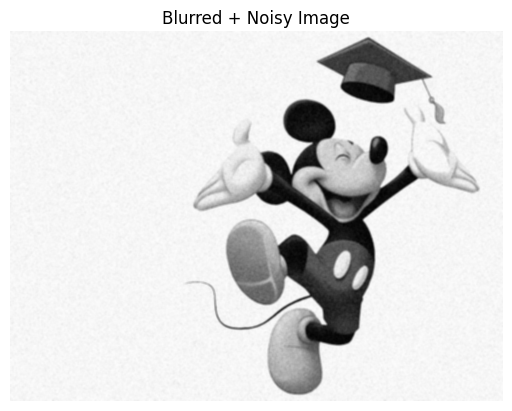

In [9]:
# Add Gaussian noise
noise = np.random.normal(0,20,img.shape)
noisy = np.clip(img + noise,0,255).astype(np.uint8)

# Blur (simulate degradation)
kernel = np.ones((5,5))/25
blur = cv2.filter2D(noisy,-1,kernel)

plt.imshow(blur,cmap='gray')
plt.title("Blurred + Noisy Image")
plt.axis('off')

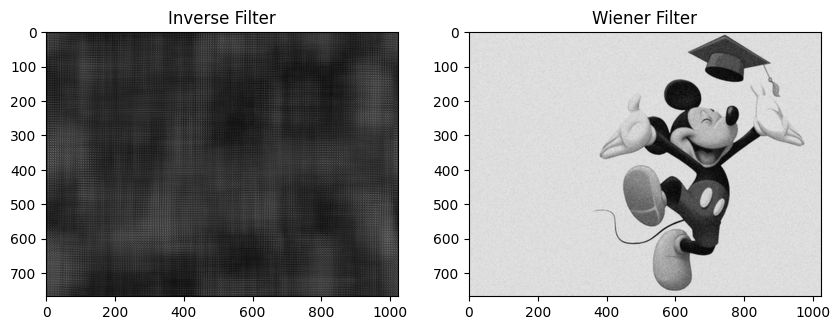

In [10]:
# FFT
G = np.fft.fft2(blur)
H = np.fft.fft2(kernel, s=img.shape)

# Inverse filter
H_inv = 1 / (H + 1e-5)
F_inv = G * H_inv
img_inv = np.abs(np.fft.ifft2(F_inv))

# Wiener filter
K = 0.01
H_conj = np.conj(H)
F_wiener = (H_conj / (np.abs(H)**2 + K)) * G
img_wiener = np.abs(np.fft.ifft2(F_wiener))

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(img_inv, cmap='gray')
plt.title("Inverse Filter")

plt.subplot(122)
plt.imshow(img_wiener, cmap='gray')
plt.title("Wiener Filter")

plt.show()